# tau = RC from discharge time-series

Cell 1: set user inputs.
Cell 2: load data, estimate `tau`, and plot the result.


In [5]:
# ============================================================
# Cell 1. User inputs
# ============================================================

file_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. [Lead] ionic DC-TENG\0. 실험자료\8. Gibeom touch\260506_이론 기반 파이썬\Fig S\새 폴더\Cut_260415_DC_300Vpp_9V_HERE.csv"

sheet_name = 0

# Data layout
# For headerless CSV, keep has_header = False and use column indices.
has_header = False
time_column_index = 0
voltage_column_index = 1

# Scale factors to convert units if needed
# Example: ms -> s  => time_scale = 1e-3
# Example: mV -> V  => voltage_scale = 1e-3
time_scale = 1.0
voltage_scale = 1.0

# Optional fitting window on the original time axis
start_time = None
end_time = None

# Smoothing for noisy data
# 'none', 'rolling_mean', 'rolling_median', 'median_then_mean'
smoothing_method = 'median_then_mean'
median_window_points = 7
mean_window_points = 7
fit_on_smoothed_signal = True

# Offset handling
# If force_offset is None, V_inf is estimated from the tail average.
force_offset = None
tail_fraction_for_offset = 0.10

# Signal polarity
# 'auto', 'positive', or 'negative'
polarity = 'auto'

# Export fitted trace if needed
save_fit_csv = False
fit_csv_path = r''


,0,1
0,0.0000,11.28
1,0.0001,11.28
2,0.0002,11.28
3,0.0003,11.28
4,0.0004,11.28


Columns: [0, 1]


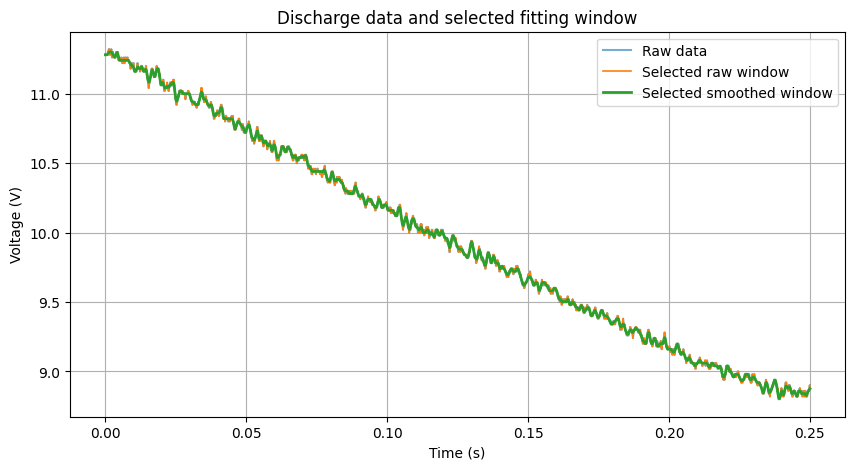

Fit method       : Nonlinear fit (scipy.optimize.curve_fit)
Fit signal       : Smoothed
Smoothing method : median_then_mean
tau (s)          : 0.536109
V_inf (V)        : 4.41509
Amplitude (V)    : 6.93211
R^2 on fit signal: 0.998411
R^2 on raw data  : 0.997890
Scipy available  : True


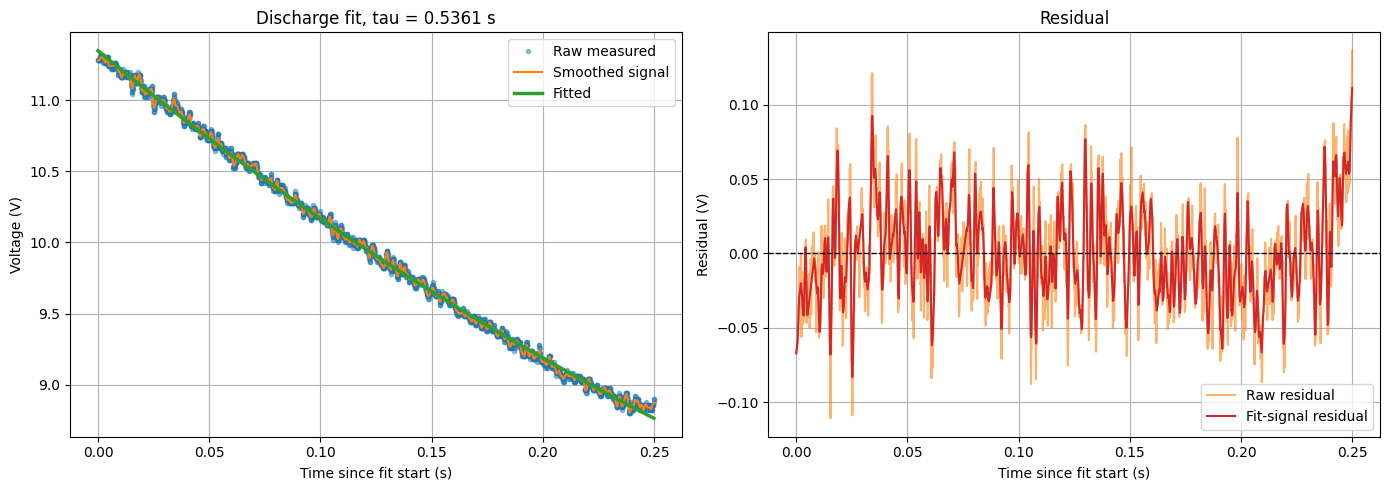

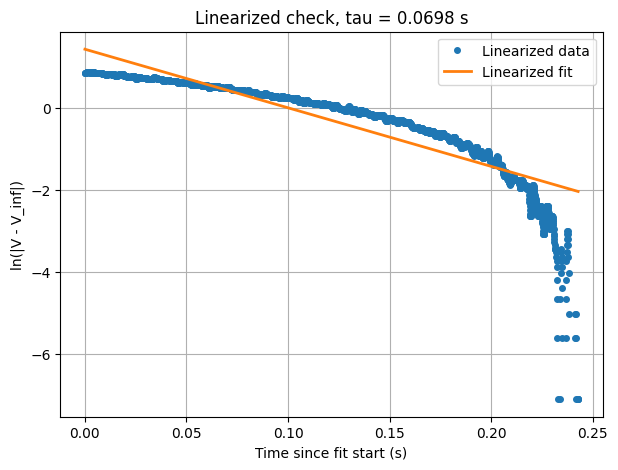

,time_s,voltage_measured_raw_V,voltage_measured_smoothed_V,voltage_used_for_fit_V,voltage_fitted_V,residual_fit_signal_V,residual_raw_V
0,0.0000,11.28,11.28,11.28,11.347193,-0.067193,-0.067193
1,0.0001,11.28,11.28,11.28,11.345900,-0.065900,-0.065900
2,0.0002,11.28,11.28,11.28,11.344608,-0.064608,-0.064608
3,0.0003,11.28,11.28,11.28,11.343315,-0.063315,-0.063315
4,0.0004,11.28,11.28,11.28,11.342023,-0.062023,-0.062023


In [6]:
# ============================================================
# Cell 2. Load, calculate, and plot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.optimize import curve_fit
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True


def load_table(file_path, sheet_name=0, has_header=False):
    path = Path(file_path)
    suffix = path.suffix.lower()
    header = 0 if has_header else None

    if suffix == '.csv':
        return pd.read_csv(path, header=header)
    if suffix in {'.xlsx', '.xls'}:
        return pd.read_excel(path, sheet_name=sheet_name, header=header)

    raise ValueError(f'Unsupported file type: {suffix}')


def exp_decay_model(t, v_inf, amplitude, tau):
    return v_inf + amplitude * np.exp(-t / tau)


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return 1.0 - ss_res / ss_tot


def smooth_signal(y, method='none', median_window=5, mean_window=5):
    s = pd.Series(y)

    if method == 'none':
        return s.to_numpy(dtype=float)
    if method == 'rolling_mean':
        return s.rolling(mean_window, center=True, min_periods=1).mean().to_numpy(dtype=float)
    if method == 'rolling_median':
        return s.rolling(median_window, center=True, min_periods=1).median().to_numpy(dtype=float)
    if method == 'median_then_mean':
        y1 = s.rolling(median_window, center=True, min_periods=1).median()
        y2 = y1.rolling(mean_window, center=True, min_periods=1).mean()
        return y2.to_numpy(dtype=float)

    raise ValueError(f'Unknown smoothing method: {method}')


if not file_path:
    raise ValueError('Please set file_path in Cell 1 first.')

df = load_table(file_path=file_path, sheet_name=sheet_name, has_header=has_header)
display(df.head())
print('Columns:', list(df.columns))

if time_column_index >= df.shape[1]:
    raise IndexError(f'time_column_index={time_column_index} is out of range for {df.shape[1]} columns.')
if voltage_column_index >= df.shape[1]:
    raise IndexError(f'voltage_column_index={voltage_column_index} is out of range for {df.shape[1]} columns.')

time_raw = pd.to_numeric(df.iloc[:, time_column_index], errors='coerce').to_numpy(dtype=float)
voltage_raw = pd.to_numeric(df.iloc[:, voltage_column_index], errors='coerce').to_numpy(dtype=float)

mask_finite = np.isfinite(time_raw) & np.isfinite(voltage_raw)
time_raw = time_raw[mask_finite] * time_scale
voltage_raw = voltage_raw[mask_finite] * voltage_scale

order = np.argsort(time_raw)
time_raw = time_raw[order]
voltage_raw = voltage_raw[order]

window_mask = np.ones_like(time_raw, dtype=bool)
if start_time is not None:
    window_mask &= time_raw >= start_time
if end_time is not None:
    window_mask &= time_raw <= end_time

time_fit = time_raw[window_mask]
voltage_fit_raw = voltage_raw[window_mask]

if len(time_fit) < 8:
    raise ValueError('Not enough points in the selected fitting window.')

time_fit = time_fit - time_fit[0]
voltage_fit_smooth = smooth_signal(
    voltage_fit_raw,
    method=smoothing_method,
    median_window=median_window_points,
    mean_window=mean_window_points,
)
voltage_fit = voltage_fit_smooth if fit_on_smoothed_signal else voltage_fit_raw

plt.figure()
plt.plot(time_raw, voltage_raw, label='Raw data', alpha=0.6)
plt.plot(time_raw[window_mask], voltage_fit_raw, label='Selected raw window', linewidth=1.2)
plt.plot(time_raw[window_mask], voltage_fit_smooth, label='Selected smoothed window', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Discharge data and selected fitting window')
plt.legend()
plt.show()

tail_count = max(3, int(len(voltage_fit) * tail_fraction_for_offset))
v_inf_guess = float(force_offset) if force_offset is not None else float(np.mean(voltage_fit[-tail_count:]))
delta_guess = voltage_fit - v_inf_guess

if polarity == 'positive':
    sign = 1.0
elif polarity == 'negative':
    sign = -1.0
else:
    sign = 1.0 if abs(delta_guess[0]) >= abs(np.min(delta_guess)) else -1.0

y_linear = sign * (voltage_fit - v_inf_guess)
positive_mask = y_linear > 0

if np.count_nonzero(positive_mask) < 5:
    raise ValueError('Not enough positive points after offset/polarity handling. Check the fitting window or force_offset.')

t_lin = time_fit[positive_mask]
y_lin = y_linear[positive_mask]
ln_y = np.log(y_lin)

slope, intercept = np.polyfit(t_lin, ln_y, 1)
tau_linear = -1.0 / slope
amp_linear = np.exp(intercept)
amplitude_linear_signed = sign * amp_linear

fit_method = 'Linearized fit'
v_inf = v_inf_guess
amplitude = amplitude_linear_signed
tau = tau_linear

if SCIPY_AVAILABLE:
    p0 = [v_inf_guess, amplitude_linear_signed, tau_linear]
    lower = [-np.inf, -np.inf, 0.0]
    upper = [np.inf, np.inf, np.inf]

    try:
        popt, _ = curve_fit(
            exp_decay_model,
            time_fit,
            voltage_fit,
            p0=p0,
            bounds=(lower, upper),
            maxfev=20000,
        )
        v_inf, amplitude, tau = popt
        fit_method = 'Nonlinear fit (scipy.optimize.curve_fit)'
    except Exception as exc:
        print('Nonlinear fit failed. Falling back to linearized fit.')
        print('Reason:', exc)

voltage_pred = exp_decay_model(time_fit, v_inf, amplitude, tau)
fit_r2 = r_squared(voltage_fit, voltage_pred)
fit_r2_raw = r_squared(voltage_fit_raw, voltage_pred)

print(f'Fit method       : {fit_method}')
print(f"Fit signal       : {'Smoothed' if fit_on_smoothed_signal else 'Raw'}")
print(f'Smoothing method : {smoothing_method}')
print(f'tau (s)          : {tau:.6g}')
print(f'V_inf (V)        : {v_inf:.6g}')
print(f'Amplitude (V)    : {amplitude:.6g}')
print(f'R^2 on fit signal: {fit_r2:.6f}')
print(f'R^2 on raw data  : {fit_r2_raw:.6f}')
print(f'Scipy available  : {SCIPY_AVAILABLE}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(time_fit, voltage_fit_raw, 'o', ms=3, alpha=0.45, label='Raw measured')
axes[0].plot(time_fit, voltage_fit_smooth, '-', lw=1.5, label='Smoothed signal')
axes[0].plot(time_fit, voltage_pred, '-', lw=2.5, label='Fitted')
axes[0].set_xlabel('Time since fit start (s)')
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title(f'Discharge fit, tau = {tau:.4g} s')
axes[0].legend()

residual = voltage_fit - voltage_pred
residual_raw = voltage_fit_raw - voltage_pred
axes[1].plot(time_fit, residual_raw, color='tab:orange', alpha=0.6, label='Raw residual')
axes[1].plot(time_fit, residual, color='tab:red', label='Fit-signal residual')
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Time since fit start (s)')
axes[1].set_ylabel('Residual (V)')
axes[1].set_title('Residual')
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(t_lin, np.log(y_lin), 'o', ms=4, label='Linearized data')
plt.plot(t_lin, slope * t_lin + intercept, '-', lw=2, label='Linearized fit')
plt.xlabel('Time since fit start (s)')
plt.ylabel('ln(|V - V_inf|)')
plt.title(f'Linearized check, tau = {tau_linear:.4g} s')
plt.legend()
plt.show()

fit_result = pd.DataFrame({
    'time_s': time_fit,
    'voltage_measured_raw_V': voltage_fit_raw,
    'voltage_measured_smoothed_V': voltage_fit_smooth,
    'voltage_used_for_fit_V': voltage_fit,
    'voltage_fitted_V': voltage_pred,
    'residual_fit_signal_V': residual,
    'residual_raw_V': residual_raw,
})

display(fit_result.head())

if save_fit_csv:
    if not fit_csv_path:
        raise ValueError('Please set fit_csv_path when save_fit_csv=True.')
    fit_result.to_csv(fit_csv_path, index=False)
    print(f'Fit result exported to: {fit_csv_path}')
